In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pdfplumber

## Extração de temas do Quadro Comparativo

In [3]:
pdf_path = "DOC-Quadro-Comparativo---SF249584956519-20241210.pdf"

# Definimos onde as divisões verticais devem ficar (eixo X)
# Ajustei os valores baseados no seu log do PyMuPDF
# [Início, Divisão 1, Divisão 2, Divisão 3, Fim]
colunas_x = [65, 245, 425, 705, 780]

table_settings = {
    "vertical_strategy": "explicit",
    "explicit_vertical_lines": colunas_x,
    "horizontal_strategy": "text",  # Como não tem linhas horizontais, usamos o alinhamento do texto
    "intersection_tolerance": 15,    # Tolerância para textos levemente desalinhados
}

all_data = []

print("Iniciando extração...")

with pdfplumber.open(pdf_path) as pdf:
    for i, page in enumerate(pdf.pages):
        # Extrai a tabela usando as coordenadas manuais
        table = page.extract_table(table_settings)
        
        if table:
            for row in table:
                print(row)
                # Limpeza básica de cada célula
                clean_row = [str(cell).replace('\n', ' ').strip() if cell else "" for cell in row]
                
                # Regra de ouro: Só aceitamos a linha se a primeira célula 
                # (Emenda) começar com um número ou for o cabeçalho
                if clean_row[0] and (clean_row[0].isdigit() or "Emenda" in clean_row[0]):
                    all_data.append(clean_row)
        
        if i % 50 == 0:
            print(f"Páginas processadas: {i}")
        break



Iniciando extração...
['', '', '', 'SF/2423']
['', '', '', '']
['Emenda Autor', 'TEMA', 'Objeto', 'Análise']
['', '', '', '']
['1 Senador Esperidião Amin', 'Transição - Compensação Benefícios', 'Propõe estabelecer que o recolhimento a fundo estadual ou', 'REJEITADA']
['(PP/SC)', 'ICMS', 'distrital configura condição onerosa para fruição de incentivo ou', '']
['', '', 'benefício fiscal.', '']
['', '', '', '']
['2 Senador Esperidião Amin', 'Regime Específico - Combustíveis', 'Propõe alterar a redação ao § 6° do art. 169, estabelecendo que, a', 'ACATADA']
['(PP/SC)', '', 'partir de 2029, a alíquota do IBS será fixada de modo a não', '']
['', '', 'exceder a carga tributária calculada conforme o § 5º, reajustada', '']
['', '', 'pela variação do preço médio ponderado de venda ao consumidor', '']
['', '', 'final, considerando os 12 meses anteriores a julho do ano anterior', '']
['', '', 'ao da fixação da alíquota.', '']
['', '', '', '']
['3 Senador Esperidião Amin', 'Regime Diferenciado CBS -

In [4]:
import pdfplumber
import pandas as pd
import re

pdf_path = "DOC-Quadro-Comparativo---SF249584956519-20241210.pdf"

# Suas divisórias coordenadas (ajustadas conforme o log anterior)
colunas_x = [65, 245, 425, 705, 780] 

table_settings = {
    "vertical_strategy": "explicit",
    "explicit_vertical_lines": colunas_x,
    "horizontal_strategy": "text",
    "intersection_tolerance": 15,
}

all_emendas = []
emenda_atual = None

print("Iniciando extração com acumulação de linhas...")

with pdfplumber.open(pdf_path) as pdf:
    for i, page in enumerate(pdf.pages):
        table = page.extract_table(table_settings)
        
        if table:
            for row in table:
                # 1. Limpeza básica
                clean_row = [str(cell).strip() if cell else "" for cell in row]
                
                # Ignora linhas totalmente vazias ou ruídos de rodapé/cabeçalho
                if not any(clean_row) or "SF/" in clean_row[3] or "Emenda Autor" in clean_row[0]:
                    continue

                # 2. Identifica se a linha é o INÍCIO de uma nova emenda
                # Checamos se a primeira coluna começa com um número (ex: "1 Senador...")
                match_inicio = re.match(r'^(\d+)\s+(.*)', clean_row[0])
                
                if match_inicio:
                    # Se já vínhamos processando uma emenda, salva ela antes de começar a nova
                    if emenda_atual:
                        all_emendas.append(emenda_atual)
                    
                    numero_emenda = match_inicio.group(1)
                    autor_inicial = match_inicio.group(2)
                    
                    # Cria o dicionário da nova emenda
                    emenda_atual = {
                        "Emenda": numero_emenda,
                        "Autor": autor_inicial,
                        "Tema": clean_row[1],
                        "Objeto": clean_row[2],
                        "Análise": clean_row[3]
                    }
                else:
                    # 3. Se NÃO começa com número, é continuação da emenda anterior
                    if emenda_atual:
                        if clean_row[0]: emenda_atual["Autor"] += " " + clean_row[0]
                        if clean_row[1]: emenda_atual["Tema"] += " " + clean_row[1]
                        if clean_row[2]: emenda_atual["Objeto"] += " " + clean_row[2]
                        if clean_row[3]: emenda_atual["Análise"] += " " + clean_row[3]

    # Não esqueça de salvar a última emenda processada após o loop
    if emenda_atual:
        all_emendas.append(emenda_atual)

# Criar o DataFrame
df = pd.DataFrame(all_emendas)

# Limpeza final: remove espaços duplos criados pela junção de linhas
for col in ["Autor", "Tema", "Objeto", "Análise"]:
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True).str.strip()

print(f"Sucesso! {len(df)} emendas completas extraídas.")

# Visualizar as primeiras linhas
print(df.head())

# Salvar
#df.to_excel("quadro_comparativo_final.xlsx", index=False)

Iniciando extração com acumulação de linhas...
Sucesso! 1976 emendas completas extraídas.
  Emenda                                      Autor  \
0      1            Senador Esperidião Amin (PP/SC)   
1      2            Senador Esperidião Amin (PP/SC)   
2      3            Senador Esperidião Amin (PP/SC)   
3      4  Senador Mecias de Jesus (REPUBLICANOS/RR)   
4      5  Senador Mecias de Jesus (REPUBLICANOS/RR)   

                                          Tema  \
0      Transição - Compensação Benefícios ICMS   
1             Regime Específico - Combustíveis   
2  Regime Diferenciado CBS - Regime Automotivo   
3                      Áreas de Livre Comércio   
4                      Áreas de Livre Comércio   

                                              Objeto    Análise  
0  Propõe estabelecer que o recolhimento a fundo ...  REJEITADA  
1  Propõe alterar a redação ao § 6° do art. 169, ...    ACATADA  
2  Propõe nova redação aos incisos do caput do ar...  REJEITADA  
3  Propõe incl

In [5]:
set(range(1, 1997)) - set(df["Emenda"].apply(lambda x: int(x)).values.tolist())

{44,
 166,
 168,
 169,
 215,
 224,
 256,
 263,
 837,
 838,
 839,
 842,
 1243,
 1253,
 1264,
 1265,
 1275,
 1318,
 1619,
 1672,
 1746}

In [6]:
df

,Emenda,Autor,Tema,Objeto,Análise
0,1,Senador Esperidião Amin (PP/SC),Transição - Compensação Benefícios ICMS,Propõe estabelecer que o recolhimento a fundo ...,REJEITADA
1,2,Senador Esperidião Amin (PP/SC),Regime Específico - Combustíveis,"Propõe alterar a redação ao § 6° do art. 169, ...",ACATADA
2,3,Senador Esperidião Amin (PP/SC),Regime Diferenciado CBS - Regime Automotivo,Propõe nova redação aos incisos do caput do ar...,REJEITADA
3,4,Senador Mecias de Jesus (REPUBLICANOS/RR),Áreas de Livre Comércio,Propõe incluir a suspensão da incidência do IB...,ACATADA
4,5,Senador Mecias de Jesus (REPUBLICANOS/RR),Áreas de Livre Comércio,Propõe incluir créditos presumidos de IBS e CB...,REJEITADA
...,...,...,...,...,...
1971,1993,Senador Nelsinho Trad (PSD/MS),Simples Nacional,Acrescenta o § 12-B ao art. 26 da Lei Compleme...,REJEITADA
1972,1994,Senador Rogério Carvalho (PT/SE),Imposto Seletivo (Incidência),Propõe adequar o texto do art. 411 à lógica tr...,ACATADA
1973,1995,Senador Humberto Costa (PT/PE),Diferimento - produtores rurais,Estabelece diferimento do IBS e CBS para insum...,ACATADA
1974,1996,Senador Flávio Bolsonaro (PL/RJ),Imposto Seletivo (Incidência),Inclui artigos para estruturar o Imposto Selet...,ACATADA


## Processamento dos temas

In [31]:
# Configuração estética para o artigo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

def plot_tema_dist(df, col="Tema", top_n=30):
    # 1. Cálculo das frequências
    counts = df[col].value_counts().reset_index()
    counts.columns = [col, "Frequência"]
    
    # 2. Filtragem para garantir legibilidade (Top N)
    # Com 200+ temas, focar nos mais representativos é melhor para o paper
    plot_df = counts.head(top_n)
    
    # 3. Criação do gráfico
    plt.figure(figsize=(12, 10))
    
    ax = sns.barplot(
        data=plot_df,
        x="Frequência",
        y=col,
        hue=col,
        palette="viridis",
        legend=False
    )
    
    # 4. Ajustes finos
    plt.title(f"Top {top_n} Temas mais Frequentes - PLP 68/2024", fontsize=15, pad=20)
    plt.xlabel("Quantidade de Emendas", fontsize=12)
    plt.ylabel("Tema", fontsize=12)
    
    # Adiciona os números nas barras para facilitar a leitura rápida
    for i in ax.containers:
        ax.bar_label(i, padding=5)

    plt.tight_layout()
    plt.show()

In [9]:
df[df["Tema"] == ""]

,Emenda,Autor,Tema,Objeto,Análise
1861,1883,Senador Efraim Filho (UNIÃO/PB),,Introduz a possibilidade de transferir crédito...,REJEITADA
1883,1905,Senadora Augusta Brito (PT/CE),,Institui o uso compulsório da Nota Fiscal de S...,REJEITADA


In [19]:
sorted(df["Tema"].unique().tolist())

['',
 'Avaliação Quinquenal',
 'Avaliação Quinquenal - Audiências públicas',
 'Avaliação Quinquenal - CBNA',
 'Avaliação Quinquenal - Contratos vigentes',
 'Avaliação Quinquenal - comparativos internacionais',
 'Bens de Capital',
 'Bens de Capital - Ausência ato conjunto',
 'Bens de Capital - Concessionárias',
 'Bens de Capital - Construção Civil',
 'Bens de Capital - Locação',
 'Bens de Capital - Produtor Rural',
 'Bens de Capital - Reidi',
 'Bens de Capital - Reporto',
 'Bens de Capital - Retid',
 'Bens de Capital - Simples Nacional',
 'CBNA',
 'CBNA - alimentos coloniais',
 'CBNA - arroz em casca',
 'CBNA - arroz todos os tipos',
 'CBNA - bacalhau',
 'CBNA - bebidas lácteas',
 'CBNA - bolachas e biscoitos',
 'CBNA - castanhas',
 'CBNA - cães e gatos',
 'CBNA - erva mate',
 'CBNA - farinhas, açaí, tapioca, doces caseiros',
 'CBNA - incluir produtos',
 'CBNA - leite cru',
 'CBNA - mel',
 'CBNA - pessoas com erros inatos metabolismo',
 'CBNA - sucos',
 'CBNA - óleos vegetais',
 'CBNA -

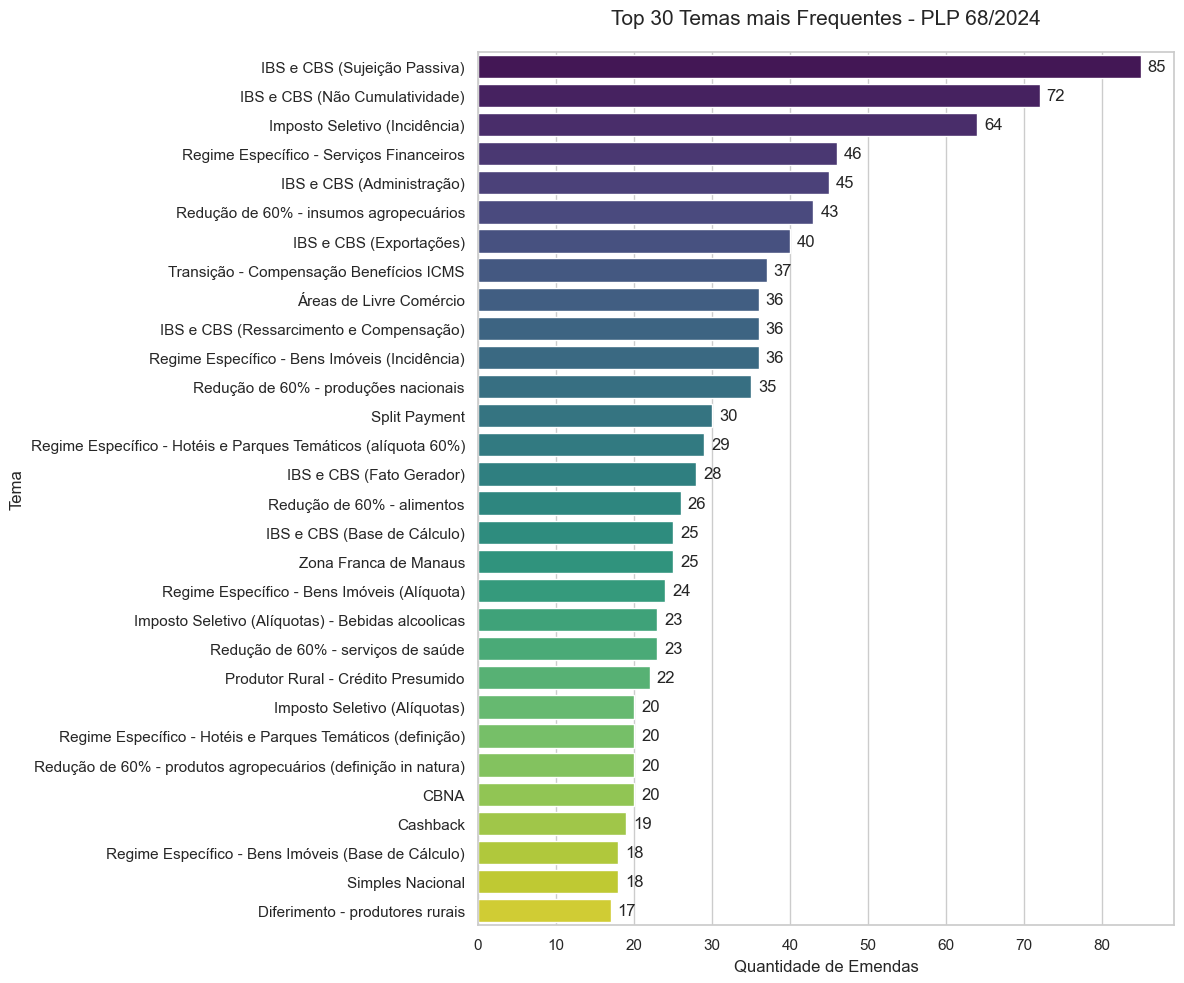

In [32]:
plot_tema_dist(df)

In [17]:
df["Tema"].value_counts()

Tema
IBS e CBS (Sujeição Passiva)                       85
IBS e CBS (Não Cumulatividade)                     72
Imposto Seletivo (Incidência)                      64
Regime Específico - Serviços Financeiros           46
IBS e CBS (Administração)                          45
                                                   ..
Zona Franca de Manaus e ALC                         1
Escola de Administração Fazendária                  1
Redução a zero - dispositivos de acessibilidade     1
Redução de 60% - dispositivos de acessibilidade     1
SAF                                                 1
Name: count, Length: 263, dtype: int64

In [33]:
def extrair_macro(tema):
    if not tema or tema == '':
        return "Não Identificado"
    
    # 1. Remove o que vem após o hífen
    macro = tema.split(' - ')[0]
    
    # 2. Remove o que vem antes de parênteses (ex: IBS e CBS (Alíquotas) -> IBS e CBS)
    macro = macro.split(' (')[0]
    
    return macro.strip()
    
df["Tema_Macro"] = df["Tema"].apply(extrair_macro)

In [34]:
sorted(df["Tema_Macro"].unique().tolist())

['Avaliação Quinquenal',
 'Bens de Capital',
 'CBNA',
 'Cashback',
 'Crédito presumido',
 'DTE',
 'Diferimento',
 'Disposições finais',
 'Dos programas de incentivo à cidadania fiscal',
 'Escola de Administração Fazendária',
 'Fundos de Investimentos',
 'IBS',
 'IBS e CBS',
 'Imposto Seletivo',
 'Isenção',
 'Matéria Estranha',
 'Matéria estranha',
 'Multa de ofício',
 'Não Identificado',
 'Produtor Rural',
 'Redução a zero',
 'Redução de 30%',
 'Redução de 60%',
 'Regime Aduaneiro Especial para preponderantemente exportadoras',
 'Regime Diferenciado',
 'Regime Diferenciado CBS',
 'Regime Específico',
 'Regimes de Aperfeiçoamento',
 'Regimes de Permanência Temporária',
 'Reinstitui o Reintegra',
 'SAF',
 'Simples Nacional',
 'Split Payment',
 'Tax Refund',
 'Transição',
 'ZPE',
 'Zona Franca de Manaus',
 'Zona Franca de Manaus e ALC',
 'Áreas de Livre Comércio']

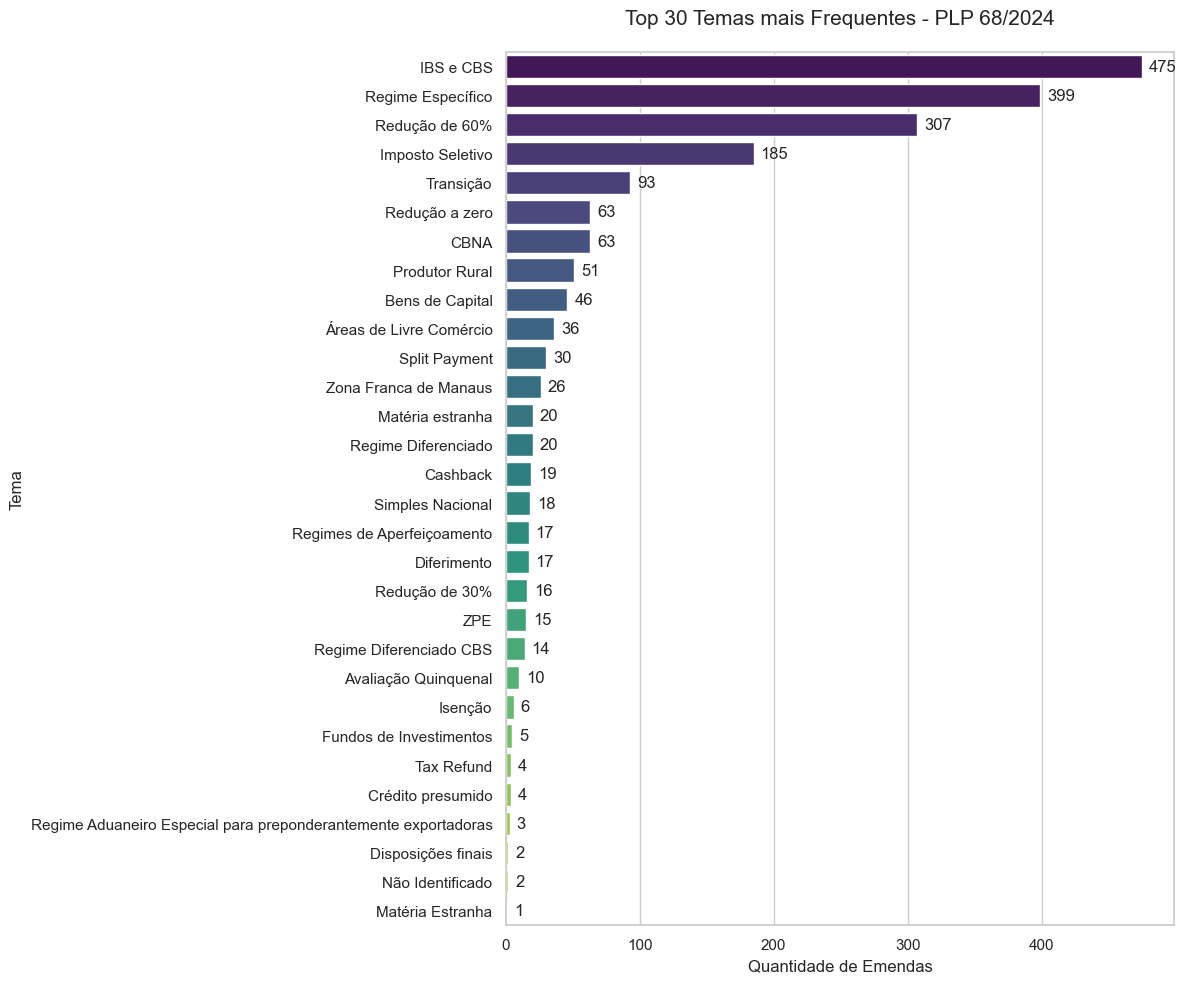

In [36]:
plot_tema_dist(df, "Tema_Macro")